# Notebook 06: Gaussian Derivative vs Gabor — Model Comparison

**Goal:** Validate the Gaussian derivative model choice from the Lindeberg framework by comparing it
against a classic Gabor filter fit on the same sparse noise RF maps.

## Why this matters

The Lindeberg (2025c,d) framework uses **affine Gaussian derivatives** as the theoretically
motivated model for simple cell receptive fields. These have well-defined covariance properties
under spatial scaling and rotation that Gabor filters do not. But Gabors are the empirical gold
standard in the literature (Jones & Palmer 1987). Before using our Gaussian-derived parameters
(σ, θ, κ) downstream, we should verify:

1. **Fit quality**: Does the Gaussian describe the RF as well as (or better than) a Gabor?
2. **Parameter consistency**: Do the spatial parameters extracted from both models agree?
3. **AIC**: Is the Gaussian's slightly simpler parametrisation justified given the data?

## Models compared

| Model | Parameters | k |
|-------|-----------|---|
| Rotated 2D Gaussian | amplitude, x₀, y₀, σ_x, σ_y, θ, offset | 7 |
| 2D Gabor | amplitude, x₀, y₀, σ_x, σ_y, θ, f, φ, offset | 9 |

The Gabor adds two parameters: spatial frequency `f` and carrier phase `φ`. Since our RF maps
are combined ON−OFF subfields (already capturing the main centre-surround structure), the
Gaussian is not obviously inferior. If Gaussian wins on AIC or ties on R², the Lindeberg
framework choice is justified with better parsimony.

## Pipeline
1. Load `all_df` (974 Gaussian-fitted neurons, R² ≥ 0.3)
2. Re-load each RF map via `reconstruct_rf`; refit with Gabor
3. Per-container crash-safe saves
4. Merge Gabor results with Gaussian results
5. Compare: R², RMSE, AIC, parameter agreement (θ, σ)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, wilcoxon
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import sys, os, warnings, time
from pathlib import Path

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    reconstruct_rf, gaussian_2d,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
warnings.filterwarnings('ignore')

print('✓ Imports successful')

✓ Imports successful


In [2]:
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
outputs_dir = base_dir / 'outputs' / 'rf_params'
ridge_dir   = outputs_dir / 'ridge'           # ridge Gaussian results live here
gabor_dir   = ridge_dir / 'gabor_fits'        # Gabor results alongside ridge
gabor_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# Load ridge Gaussian results (NOT STA) -- Gabor compares against same pipeline
all_df = pd.read_csv(ridge_dir / 'rf_params_ridge_all_containers.csv')
for col in ['sigma', 'theta', 'kappa', 'r_squared', 'rmse',
            'sigma_x', 'sigma_y', 'x0', 'y0']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

print(f'✓ Loaded Ridge Gaussian results (ridge pipeline): {len(all_df):,} neurons across'
      f' {all_df["container_id"].nunique()} containers')
print(f'  Columns: {all_df.columns.tolist()}')
print(f'  R² range: [{all_df["r_squared"].min():.3f}, {all_df["r_squared"].max():.3f}]')
print(f'  Ridge Gaussian dir : {ridge_dir}')
print(f'  Gabor output dir   : {gabor_dir}')

✓ Loaded Ridge Gaussian results (ridge pipeline): 878 neurons across 17 containers
  Columns: ['sigma', 'theta', 'kappa', 'x0', 'y0', 'amplitude', 'sigma_x', 'sigma_y', 'dominant_subfield', 'r_squared', 'rmse', 'converged', 'message', 'cell_id', 'grid_size', 'pixel_size_deg', 'stim_name', 'n_presentations', 'response_delay', 'response_window', 'method', 'n_lags', 'best_lag', 'best_lag_ms', 'ridge_lambda', 'cortex_x_um', 'cortex_y_um', 'container_id', 'exp_id', 'cre_line', 'depth_um']
  R² range: [0.300, 0.937]
  Ridge Gaussian dir : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge
  Gabor output dir   : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/gabor_fits


---

## Part 1: Gabor Model Definition

A 2D Gabor is a sinusoidal carrier modulated by a Gaussian envelope:

$$G(x, y) = A \cdot \exp\!\left(-\frac{x'^2}{2\sigma_x^2} - \frac{y'^2}{2\sigma_y^2}\right)
   \cdot \cos(2\pi f x' + \phi) + \text{offset}$$

where $x' = (x-x_0)\cos\theta + (y-y_0)\sin\theta$, 
$y' = -(x-x_0)\sin\theta + (y-y_0)\cos\theta$.

**9 free parameters**: amplitude $A$, centre $(x_0, y_0)$, Gaussian axes $(\sigma_x, \sigma_y)$,
orientation $\theta$, spatial frequency $f$, phase $\phi$, baseline offset.

The Gaussian model has 7 parameters (no $f$, no $\phi$).

**AIC** = $n \ln(\text{SS}_{\text{res}}/n) + 2k$ — lower is better; penalises extra parameters.

In [3]:
def gabor_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, theta, frequency, phase, offset):
    """2D Gabor filter: Gaussian envelope * sinusoidal carrier.
    
    Parameters match gaussian_2d convention plus frequency (cycles/pixel)
    and phase (radians). Returns flattened array for curve_fit.
    """
    x, y = xy
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    xp =  (x - x0) * cos_t + (y - y0) * sin_t   # along major axis
    yp = -(x - x0) * sin_t + (y - y0) * cos_t   # along minor axis
    envelope = np.exp(-0.5 * (xp**2 / sigma_x**2 + yp**2 / sigma_y**2))
    carrier  = np.cos(2 * np.pi * frequency * xp + phase)
    return (amplitude * envelope * carrier + offset).ravel()


def fit_gabor(rf_map, pixel_size_deg, gaussian_row=None):
    """Fit a 2D Gabor to an RF map.
    
    Args:
        rf_map: 2D array (ON - OFF combined subfield, pixel units)
        pixel_size_deg: degrees per pixel
        gaussian_row: optional Series with Gaussian fit results for warm-starting
                      (uses x0, y0, sigma_x, sigma_y, theta as initial guesses)
    
    Returns:
        dict with Gabor parameters and fit metrics, or None on failure.
    """
    ny, nx = rf_map.shape
    x_idx  = np.arange(nx)
    y_idx  = np.arange(ny)
    xx, yy = np.meshgrid(x_idx, y_idx)
    xy_data = (xx.ravel(), yy.ravel())
    z_data  = rf_map.ravel().astype(float)

    n = len(z_data)

    # --- Initial guesses ---
    # Warm-start from Gaussian fit if available; otherwise use moments
    if gaussian_row is not None and not np.isnan(gaussian_row.get('x0', np.nan)):
        pix = pixel_size_deg
        x0_init    = gaussian_row['x0'] / pix
        y0_init    = gaussian_row['y0'] / pix
        sx_init    = max(gaussian_row['sigma_x'] / pix, 0.5)
        sy_init    = max(gaussian_row['sigma_y'] / pix, 0.5)
        theta_init = np.deg2rad(gaussian_row['theta'])
    else:
        abs_rf = np.abs(rf_map)
        total  = abs_rf.sum() or 1.0
        x0_init = (xx * abs_rf).sum() / total
        y0_init = (yy * abs_rf).sum() / total
        sx_init = sy_init = min(nx, ny) / 6.0
        theta_init = 0.0

    amp_init  = float(rf_map.max() - rf_map.min())
    off_init  = float(rf_map.mean())
    # Frequency: start at 1 cycle per 2*sigma (reasonable for V1)
    freq_init = 1.0 / (2.0 * max(sx_init, 1.0))
    phase_init = 0.0

    p0 = [amp_init, x0_init, y0_init, sx_init, sy_init,
          theta_init, freq_init, phase_init, off_init]

    # --- Bounds ---
    lower = [-np.inf, 0,    0,    0.3,  0.3,  -np.pi, 0.01, -np.pi, -np.inf]
    upper = [ np.inf, nx-1, ny-1, nx/2, ny/2,  np.pi, 1.0,   np.pi,  np.inf]

    try:
        popt, _ = curve_fit(gabor_2d, xy_data, z_data,
                            p0=p0, bounds=(lower, upper),
                            maxfev=20000)
        converged = True
    except Exception:
        popt      = np.array(p0, dtype=float)
        converged = False

    amp, x0, y0, sx, sy, theta, freq, phase, offset = popt
    k_gabor = 9

    # --- Fit metrics ---
    fitted   = gabor_2d(xy_data, *popt)
    ss_res   = np.sum((z_data - fitted) ** 2)
    ss_tot   = np.sum((z_data - z_data.mean()) ** 2)
    r2       = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
    rmse     = np.sqrt(ss_res / n)
    aic      = n * np.log(ss_res / n) + 2 * k_gabor if ss_res > 0 else np.inf

    # --- Convert to degrees ---
    pix = pixel_size_deg
    sx_deg = abs(sx) * pix
    sy_deg = abs(sy) * pix
    theta_deg = np.rad2deg(theta) % 180
    sigma_gabor = np.sqrt(sx_deg * sy_deg)  # geometric mean
    kappa_gabor = max(sx_deg, sy_deg) / min(sx_deg, sy_deg) if min(sx_deg, sy_deg) > 0 else np.nan
    freq_cpd    = freq / pix  # cycles per degree

    return {
        'r2_gabor':       float(r2),
        'rmse_gabor':     float(rmse),
        'aic_gabor':      float(aic),
        'converged_gabor': converged,
        'sigma_gabor':    float(sigma_gabor),
        'theta_gabor':    float(theta_deg),
        'kappa_gabor':    float(kappa_gabor),
        'freq_cpd':       float(freq_cpd),
        'phase_rad':      float(phase),
    }


def compute_aic_gaussian(rf_map, gaussian_row, pixel_size_deg):
    """Re-compute AIC for the Gaussian fit from saved parameters.
    
    Uses the stored RMSE to back-calculate SS_res without refitting.
    AIC = n * log(SS_res / n) + 2 * k_gaussian
    """
    n       = rf_map.size
    k_gauss = 7
    rmse    = gaussian_row.get('rmse', np.nan)
    if np.isnan(rmse) or rmse <= 0:
        return np.nan
    ss_res = rmse**2 * n
    return n * np.log(ss_res / n) + 2 * k_gauss


print('✓ gabor_2d, fit_gabor, compute_aic_gaussian defined')

✓ gabor_2d, fit_gabor, compute_aic_gaussian defined


---

## Part 2: Batch Gabor Fitting

For each neuron in `all_df` (those that passed R² ≥ 0.3 Gaussian fit):
1. Re-load the RF map via `reconstruct_rf`
2. Fit Gabor with warm-start from Gaussian parameters
3. Back-compute Gaussian AIC from stored RMSE
4. Save per-container CSV immediately (crash-safe)

Skips any container already saved.

In [4]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps: single NWB read + single ridge solve → {cell_id: (rf_map, pix)}
# This is the inner core of batch_extract_spatial_parameters, stopping before
# Gaussian fitting. Gabor curve_fit is then the only work done per neuron.
# ---------------------------------------------------------------------------
from sklearn.linear_model import RidgeCV
from rf_analysis.sparse_noise import _build_design_matrix, _pixel_size, _LAMBDA_GRID

def batch_get_rf_maps(dataset, cell_ids,
                      n_lags=8, response_delay=4, response_window=5):
    """Return {cell_id: (rf_map, pix_size_deg)} for all cell_ids in one pass."""
    cell_ids = list(cell_ids)

    stimuli = dataset.list_stimuli()
    stimulus_name = next(
        (s for s in stimuli if 'sparse_noise' in s),
        None
    )
    if stimulus_name is None:
        raise ValueError(f"No sparse noise stimulus. Available: {stimuli}")

    stim_table    = dataset.get_stimulus_table(stimulus_name)
    tr            = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stimulus_name)
    template      = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size      = _pixel_size(stimulus_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)
    n_pres        = len(starts)

    # Single NWB read for all neurons
    _, all_dff = dataset.get_dff_traces(cell_specimen_ids=cell_ids)
    n_cells, n_tp = all_dff.shape

    # Build X once
    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    # Response matrix Y: (n_pres, n_cells)
    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T          # (n_pres, n_cells)
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit = X[frame_valid].astype(np.float64)
    Y_fit = Y[frame_valid]

    if X_fit.shape[0] < 20:
        raise ValueError("Too few valid presentations.")

    # Single ridge solve for all neurons (shared SVD via GCV)
    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)   # (n_cells, n_features)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        from sklearn.linear_model import Ridge
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    # Per-neuron: best lag → rf_map
    rf_cache = {}
    for i, cid in enumerate(cell_ids):
        strf       = W[i].reshape(n_lags, grid_h, grid_w)
        lag_energy = np.array([np.abs(strf[lag]).max() for lag in range(n_lags)])
        best_lag   = int(np.argmax(lag_energy))
        rf_cache[cid] = (strf[best_lag], pix_size)   # (rf_map, pix)

    return rf_cache


# ---------------------------------------------------------------------------
# Main Gabor fitting loop — RF maps batched per container, Gabor fit per neuron
# ---------------------------------------------------------------------------
QUALITY_THRESHOLD = 0.3

containers = sorted(all_df['container_id'].unique())
print(f'Containers to process: {len(containers)}')

gabor_log = []
t_total   = time.time()

for c_i, container_id in enumerate(containers):
    out_file = gabor_dir / f'gabor_fits_container_{container_id}.csv'

    # --- Skip if already done ---
    if out_file.exists():
        df_done = pd.read_csv(out_file)
        print(f'  [SKIP] Container {container_id}: {len(df_done)} neurons (cached)')
        gabor_log.append({'container_id': container_id, 'status': 'cached',
                          'n_fit': len(df_done)})
        continue

    sub    = all_df[all_df['container_id'] == container_id].copy()
    exp_id = int(sub['exp_id'].iloc[0])
    print(f'\n[{c_i+1}/{len(containers)}] Container {container_id}  '
          f'({len(sub)} neurons)')

    try:
        dataset = boc.get_ophys_experiment_data(exp_id)
    except Exception as e:
        print(f'  ERROR loading experiment {exp_id}: {e}')
        gabor_log.append({'container_id': container_id, 'status': 'exp_load_error',
                          'n_fit': 0})
        continue

    # --- Batch RF maps: one NWB read + one ridge solve for whole container ---
    t0 = time.time()
    cell_ids_here = sub['cell_id'].astype(int).tolist()
    try:
        rf_cache = batch_get_rf_maps(dataset, cell_ids_here)
        print(f'  RF maps batched in {time.time()-t0:.1f}s  '
              f'({len(rf_cache)} maps)')
    except Exception as e:
        print(f'  ERROR in batch RF maps: {e}')
        gabor_log.append({'container_id': container_id, 'status': 'batch_error',
                          'n_fit': 0})
        continue

    # --- Inner loop: Gabor curve_fit only (no NWB reads, no ridge) ---
    results = []
    n_fail  = 0
    t1 = time.time()

    for j, (_, row) in enumerate(sub.iterrows()):
        cell_id = int(row['cell_id'])

        if (j + 1) % 20 == 0:
            elapsed = time.time() - t1
            rate    = (j + 1) / elapsed
            eta     = (len(sub) - j - 1) / rate
            print(f'    {j+1}/{len(sub)}  |  {rate:.1f} cells/s  |  ETA {eta:.0f}s')

        try:
            rf_map, pix = rf_cache[cell_id]

            # Gabor fit (warm-started from Gaussian params in row)
            gabor_result = fit_gabor(rf_map, pix, gaussian_row=row)

            # Gaussian AIC back-computed from stored RMSE (no refit needed)
            aic_gauss = compute_aic_gaussian(rf_map, row, pix)

            rec = {
                'cell_id':      cell_id,
                'container_id': container_id,
                'exp_id':       exp_id,
                'r2_gauss':     row['r_squared'],
                'rmse_gauss':   row.get('rmse', np.nan),
                'aic_gauss':    aic_gauss,
                **gabor_result,
            }
            results.append(rec)

        except Exception as e:
            n_fail += 1

    if results:
        df_out = pd.DataFrame(results)
        df_out.to_csv(out_file, index=False)
        elapsed = time.time() - t1
        print(f'  ✓ Saved {len(df_out)} Gabor fits  |  {n_fail} failed  '
              f'|  {elapsed:.1f}s fit time')
        gabor_log.append({'container_id': container_id, 'status': 'done',
                          'n_fit': len(df_out), 'n_fail': n_fail})
    else:
        print(f'  WARNING: no results for container {container_id}')
        gabor_log.append({'container_id': container_id, 'status': 'no_results',
                          'n_fit': 0})

print(f'\n✓ Batch Gabor fitting complete — {time.time()-t_total:.1f}s total')


Containers to process: 17
  [SKIP] Container 511507650: 55 neurons (cached)
  [SKIP] Container 511509529: 38 neurons (cached)
  [SKIP] Container 511510650: 14 neurons (cached)
  [SKIP] Container 511510670: 41 neurons (cached)
  [SKIP] Container 511510718: 36 neurons (cached)
  [SKIP] Container 511510736: 21 neurons (cached)
  [SKIP] Container 511510855: 56 neurons (cached)
  [SKIP] Container 650389885: 24 neurons (cached)
  [SKIP] Container 652842570: 68 neurons (cached)
  [SKIP] Container 653125128: 74 neurons (cached)
  [SKIP] Container 661437138: 50 neurons (cached)
  [SKIP] Container 661732156: 116 neurons (cached)
  [SKIP] Container 666589599: 35 neurons (cached)
  [SKIP] Container 680156909: 60 neurons (cached)
  [SKIP] Container 682734790: 46 neurons (cached)
  [SKIP] Container 688678764: 109 neurons (cached)
  [SKIP] Container 701412138: 35 neurons (cached)

✓ Batch Gabor fitting complete — 0.1s total


In [5]:
# Load all Gabor fit CSVs and merge with Gaussian all_df
gabor_files = sorted(gabor_dir.glob('gabor_fits_container_*.csv'))
print(f'Found {len(gabor_files)} Gabor fit files')

gabor_dfs = [pd.read_csv(f) for f in gabor_files]
gabor_df  = pd.concat(gabor_dfs, ignore_index=True)

# Merge: join on cell_id + container_id to get Gaussian params alongside Gabor params
gauss_cols = ['cell_id', 'container_id', 'sigma', 'theta', 'kappa',
              'sigma_x', 'sigma_y', 'cortex_x_um', 'cortex_y_um',
              'cre_line', 'depth_um']
cmp_df = gabor_df.merge(
    all_df[gauss_cols].rename(columns={'sigma': 'sigma_gauss',
                                       'theta': 'theta_gauss',
                                       'kappa': 'kappa_gauss'}),
    on=['cell_id', 'container_id'], how='inner'
)

# Drop any rows missing critical metrics
cmp_df = cmp_df.dropna(subset=['r2_gauss', 'r2_gabor', 'aic_gauss', 'aic_gabor'])

print(f'\n✓ Comparison dataset: {len(cmp_df):,} neurons')
print(f'\nGaussian:  mean R²={cmp_df["r2_gauss"].mean():.3f}  '
      f'mean AIC={cmp_df["aic_gauss"].mean():.1f}')
print(f'Gabor:     mean R²={cmp_df["r2_gabor"].mean():.3f}  '
      f'mean AIC={cmp_df["aic_gabor"].mean():.1f}')

# Δ AIC: negative = Gaussian is better
cmp_df['delta_aic']  = cmp_df['aic_gauss'] - cmp_df['aic_gabor']   # <0: Gaussian better
cmp_df['delta_r2']   = cmp_df['r2_gabor']  - cmp_df['r2_gauss']    # >0: Gabor better
cmp_df['winner']     = np.where(cmp_df['delta_aic'] < 0, 'Gaussian', 'Gabor')

print(f'\nΔAIC (Gauss − Gabor): mean={cmp_df["delta_aic"].mean():.2f}  '
      f'median={cmp_df["delta_aic"].median():.2f}')
print(f'  < 0 (Gaussian preferred by AIC): {(cmp_df["delta_aic"] < 0).sum()} '
      f'({100*(cmp_df["delta_aic"]<0).mean():.1f}%)')
print(f'  > 0 (Gabor preferred by AIC):    {(cmp_df["delta_aic"] > 0).sum()} '
      f'({100*(cmp_df["delta_aic"]>0).mean():.1f}%)')

# Wilcoxon signed-rank test on AIC
stat, p_aic = wilcoxon(cmp_df['aic_gauss'], cmp_df['aic_gabor'])
print(f'\nWilcoxon test (AIC): W={stat:.0f}, p={p_aic:.3e}')

Found 17 Gabor fit files

✓ Comparison dataset: 878 neurons

Gaussian:  mean R²=0.523  mean AIC=-8044.1
Gabor:     mean R²=0.248  mean AIC=-7180.6

ΔAIC (Gauss − Gabor): mean=-863.54  median=-865.03
  < 0 (Gaussian preferred by AIC): 878 (100.0%)
  > 0 (Gabor preferred by AIC):    0 (0.0%)

Wilcoxon test (AIC): W=0, p=2.624e-145


---

## Part 3: Visualisation — Fit Quality Comparison

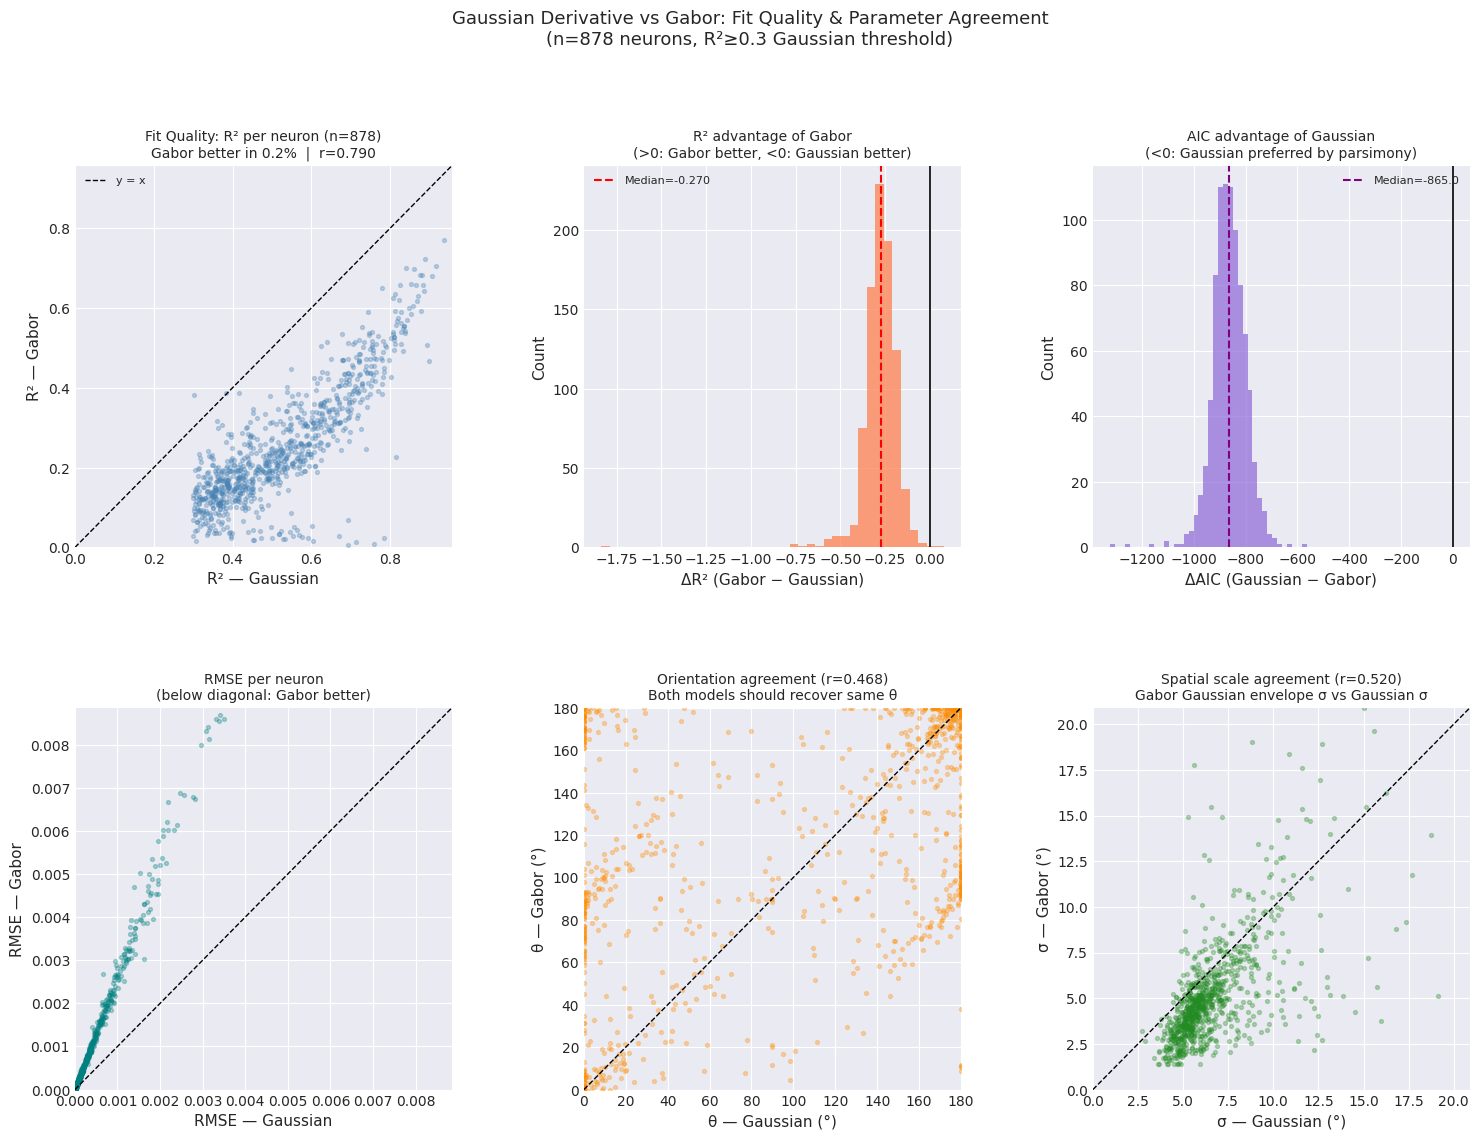

✓ Saved: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/fig_gaussian_vs_gabor_comparison.png


In [6]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── 1. R² scatter: Gaussian vs Gabor ──────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(cmp_df['r2_gauss'], cmp_df['r2_gabor'],
            alpha=0.3, s=8, rasterized=True, color='steelblue')
lims = [max(0, min(cmp_df['r2_gauss'].min(), cmp_df['r2_gabor'].min()) - 0.02),
        min(1, max(cmp_df['r2_gauss'].max(), cmp_df['r2_gabor'].max()) + 0.02)]
ax0.plot(lims, lims, 'k--', linewidth=1, label='y = x')
ax0.set_xlim(lims); ax0.set_ylim(lims)
ax0.set_xlabel('R² — Gaussian', fontsize=11)
ax0.set_ylabel('R² — Gabor', fontsize=11)
r_r2, _ = pearsonr(cmp_df['r2_gauss'], cmp_df['r2_gabor'])
above = (cmp_df['r2_gabor'] > cmp_df['r2_gauss']).mean() * 100
ax0.set_title(f'Fit Quality: R² per neuron (n={len(cmp_df):,})\n'
              f'Gabor better in {above:.1f}%  |  r={r_r2:.3f}', fontsize=10)
ax0.legend(fontsize=8)

# ── 2. ΔR² histogram ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(cmp_df['delta_r2'], bins=40, edgecolor='none', alpha=0.75, color='coral')
ax1.axvline(0, color='black', linewidth=1.2)
ax1.axvline(cmp_df['delta_r2'].median(), color='red', linestyle='--',
            label=f'Median={cmp_df["delta_r2"].median():.3f}')
ax1.set_xlabel('ΔR² (Gabor − Gaussian)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('R² advantage of Gabor\n(>0: Gabor better, <0: Gaussian better)', fontsize=10)
ax1.legend(fontsize=8)

# ── 3. ΔAIC histogram ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(cmp_df['delta_aic'], bins=40, edgecolor='none', alpha=0.75, color='mediumpurple')
ax2.axvline(0, color='black', linewidth=1.2)
ax2.axvline(cmp_df['delta_aic'].median(), color='purple', linestyle='--',
            label=f'Median={cmp_df["delta_aic"].median():.1f}')
ax2.set_xlabel('ΔAIC (Gaussian − Gabor)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('AIC advantage of Gaussian\n(<0: Gaussian preferred by parsimony)', fontsize=10)
ax2.legend(fontsize=8)

# ── 4. RMSE scatter ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(cmp_df['rmse_gauss'], cmp_df['rmse_gabor'],
            alpha=0.3, s=8, rasterized=True, color='teal')
lims_rmse = [0, max(cmp_df['rmse_gauss'].quantile(0.99),
                    cmp_df['rmse_gabor'].quantile(0.99)) * 1.05]
ax3.plot(lims_rmse, lims_rmse, 'k--', linewidth=1)
ax3.set_xlim(lims_rmse); ax3.set_ylim(lims_rmse)
ax3.set_xlabel('RMSE — Gaussian', fontsize=11)
ax3.set_ylabel('RMSE — Gabor', fontsize=11)
ax3.set_title('RMSE per neuron\n(below diagonal: Gabor better)', fontsize=10)

# ── 5. Orientation agreement: θ_gauss vs θ_gabor ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(cmp_df['theta_gauss'], cmp_df['theta_gabor'],
            alpha=0.3, s=8, rasterized=True, color='darkorange')
ax4.plot([0, 180], [0, 180], 'k--', linewidth=1)
ax4.set_xlim(0, 180); ax4.set_ylim(0, 180)
r_theta, _ = pearsonr(cmp_df['theta_gauss'], cmp_df['theta_gabor'])
ax4.set_xlabel('θ — Gaussian (°)', fontsize=11)
ax4.set_ylabel('θ — Gabor (°)', fontsize=11)
ax4.set_title(f'Orientation agreement (r={r_theta:.3f})\n'
              'Both models should recover same θ', fontsize=10)

# ── 6. σ agreement: σ_gauss vs σ_gabor ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(cmp_df['sigma_gauss'], cmp_df['sigma_gabor'],
            alpha=0.3, s=8, rasterized=True, color='forestgreen')
lims_s = [0, max(cmp_df['sigma_gauss'].quantile(0.99),
                  cmp_df['sigma_gabor'].quantile(0.99)) * 1.05]
ax5.plot(lims_s, lims_s, 'k--', linewidth=1)
ax5.set_xlim(0, lims_s[1]); ax5.set_ylim(0, lims_s[1])
r_sig, _ = pearsonr(cmp_df['sigma_gauss'], cmp_df['sigma_gabor'])
ax5.set_xlabel('σ — Gaussian (°)', fontsize=11)
ax5.set_ylabel('σ — Gabor (°)', fontsize=11)
ax5.set_title(f'Spatial scale agreement (r={r_sig:.3f})\n'
              'Gabor Gaussian envelope σ vs Gaussian σ', fontsize=10)

fig.suptitle('Gaussian Derivative vs Gabor: Fit Quality & Parameter Agreement\n'
             f'(n={len(cmp_df):,} neurons, R²≥0.3 Gaussian threshold)',
             fontsize=13, y=1.01)
plt.tight_layout()
fig_path = ridge_dir / 'fig_gaussian_vs_gabor_comparison.png'
plt.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {fig_path}')

---

## Part 4: RF Gallery — Both Fits on the Same Neurons

Show 8 neurons across the R² range, with the Gaussian fit contour (yellow) and
Gabor fit contour (cyan) overlaid on the same RF map.

✓ batch_get_rf_maps_safe defined
  ✓ exp 500855614: 1/1 maps
  ✓ exp 509644421: 1/1 maps
  ✓ exp 650389887: 1/1 maps
  ✓ exp 653552163: 1/1 maps
  ✓ exp 661753184: 1/1 maps
  ✓ exp 682054669: 1/1 maps
  ✓ exp 682734792: 1/1 maps
  ✓ exp 691763694: 1/1 maps
Plotting 8 neurons


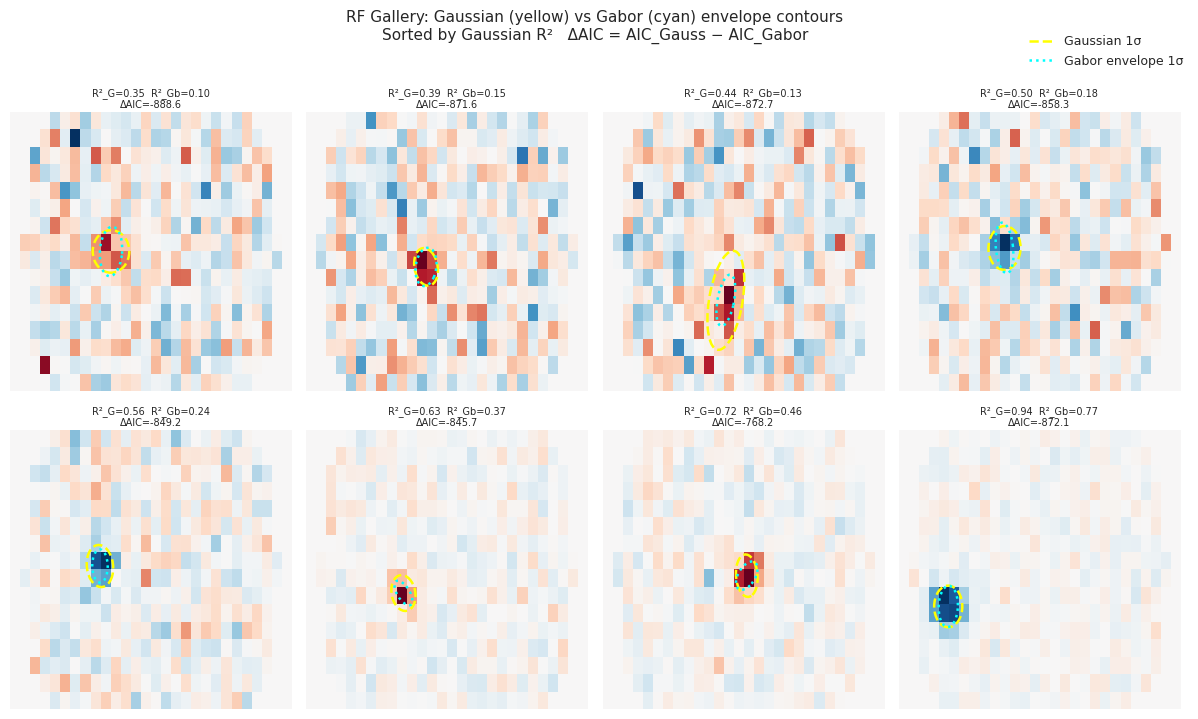

✓ Saved: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/fig_gaussian_vs_gabor_gallery.png


In [15]:
from sklearn.linear_model import RidgeCV
from rf_analysis.sparse_noise import _build_design_matrix, _pixel_size, _LAMBDA_GRID
 
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]   # experiment's order, filtered
    if not valid_ids:
        raise ValueError(f"None of the requested cell_ids found in this experiment.")
 
    stimulus_name = next(
        (s for s in dataset.list_stimuli() if 'sparse_noise' in s), None
    )
    if stimulus_name is None:
        raise ValueError("No sparse noise stimulus found.")
 
    stim_table    = dataset.get_stimulus_table(stimulus_name)
    tr            = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stimulus_name)
    template      = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size      = _pixel_size(stimulus_name)
 
    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)
 
    _, all_dff = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape
 
    X = _build_design_matrix(template, frame_indices, on_val, off_val, grid_h, grid_w, n_lags)
 
    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)
 
    frame_valid = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError("Too few valid presentations.")
 
    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        from sklearn.linear_model import Ridge
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)
 
    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out
 
print('✓ batch_get_rf_maps_safe defined')

# Figure 16: RF gallery — Gaussian (yellow) vs Gabor (cyan) envelope contours
# Uses batch_get_rf_maps_safe (defined in Cell 12) for correct cell_id ordering.

N_SHOW   = 8
gallery  = cmp_df[cmp_df['r2_gauss'] >= 0.35].sort_values('r2_gauss').reset_index(drop=True)
indices  = np.linspace(0, len(gallery) - 1, N_SHOW).astype(int)
selected = gallery.iloc[indices].reset_index(drop=True)

# ── Batch RF maps ─────────────────────────────────────────────────────────────
rf_cache = {}
for exp_id, grp in selected.groupby('exp_id'):
    cell_ids_here = grp['cell_id'].astype(int).tolist()
    try:
        dataset   = boc.get_ophys_experiment_data(int(exp_id))
        exp_cache = batch_get_rf_maps_safe(dataset, cell_ids_here)
        rf_cache.update(exp_cache)
        print(f'  ✓ exp {exp_id}: {len(exp_cache)}/{len(cell_ids_here)} maps')
    except Exception as e:
        print(f'  ✗ exp {exp_id}: {e}')

# Filter to loaded only
selected = selected[selected['cell_id'].astype(int).isin(rf_cache)].reset_index(drop=True)
print(f'Plotting {len(selected)} neurons')

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols = max(len(selected) // 2, 1)
nrows = 2 if len(selected) > ncols else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
axes = np.array(axes).flatten()

for ax_i, (_, row) in enumerate(selected.iterrows()):
    ax      = axes[ax_i]
    cell_id = int(row['cell_id'])
    rf_map, pix = rf_cache[cell_id]
    ny, nx = rf_map.shape
    vmax = max(np.abs(rf_map).max(), 1e-9)
    ax.imshow(rf_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
              aspect='auto', interpolation='nearest')

    # Gaussian 1σ ellipse (yellow dashed)
    gauss_row = all_df.loc[all_df['cell_id'] == cell_id]
    if len(gauss_row):
        gr = gauss_row.iloc[0]
        if not np.isnan(gr.get('sigma_x', np.nan)):
            ax.add_patch(Ellipse(
                xy=(gr['x0'] / pix, gr['y0'] / pix),
                width=2 * gr['sigma_x'] / pix, height=2 * gr['sigma_y'] / pix,
                angle=float(gr['theta']),
                edgecolor='yellow', facecolor='none', linewidth=1.8, linestyle='--'
            ))

    # Gabor 1σ envelope ellipse (cyan dotted)
    sigma_gab = row.get('sigma_gabor', np.nan)
    if not np.isnan(sigma_gab) and len(gauss_row):
        gr  = gauss_row.iloc[0]
        kg  = max(float(row['kappa_gabor']), 1.0) if not np.isnan(row['kappa_gabor']) else 1.0
        ax.add_patch(Ellipse(
            xy=(gr['x0'] / pix, gr['y0'] / pix),
            width=2 * sigma_gab * np.sqrt(kg) / pix,
            height=2 * sigma_gab / np.sqrt(kg) / pix,
            angle=float(row['theta_gabor']),
            edgecolor='cyan', facecolor='none', linewidth=1.8, linestyle=':'
        ))

    ax.set_title(
        f'R²_G={row["r2_gauss"]:.2f}  R²_Gb={row["r2_gabor"]:.2f}\n'
        f'ΔAIC={row["delta_aic"]:+.1f}',
        fontsize=7, pad=3
    )
    ax.axis('off')

# Hide unused axes
for ax in axes[len(selected):]:
    ax.axis('off')

fig.legend(handles=[
    Line2D([0], [0], color='yellow', linestyle='--', linewidth=1.8, label='Gaussian 1σ'),
    Line2D([0], [0], color='cyan',   linestyle=':',  linewidth=1.8, label='Gabor envelope 1σ'),
], loc='upper right', fontsize=9, bbox_to_anchor=(1.0, 1.0))

fig.suptitle(
    'RF Gallery: Gaussian (yellow) vs Gabor (cyan) envelope contours\n'
    'Sorted by Gaussian R²   ΔAIC = AIC_Gauss − AIC_Gabor',
    fontsize=11, y=1.02
)
plt.tight_layout()
gallery_path = ridge_dir / 'fig_gaussian_vs_gabor_gallery.png'
plt.savefig(gallery_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {gallery_path}')

Gabor never preferred by AIC: all ΔAIC < 0 (100.0% of neurons)
Requested: 18 neurons across 11 experiments
  ✓ exp 500855614: 3/3 RF maps loaded
  ✓ exp 501337989: 2/2 RF maps loaded
  ✓ exp 501474098: 1/1 RF maps loaded
  ✓ exp 501717543: 1/1 RF maps loaded
  ✓ exp 504642019: 2/2 RF maps loaded
  ✓ exp 650389887: 1/1 RF maps loaded
  ✓ exp 653053207: 1/1 RF maps loaded
  ✓ exp 653552163: 3/3 RF maps loaded
  ✓ exp 662358233: 1/1 RF maps loaded
  ✓ exp 666589601: 2/2 RF maps loaded
  ✓ exp 682054669: 1/1 RF maps loaded

✓ Plotting 18 neurons  (skipped 0 with load errors)


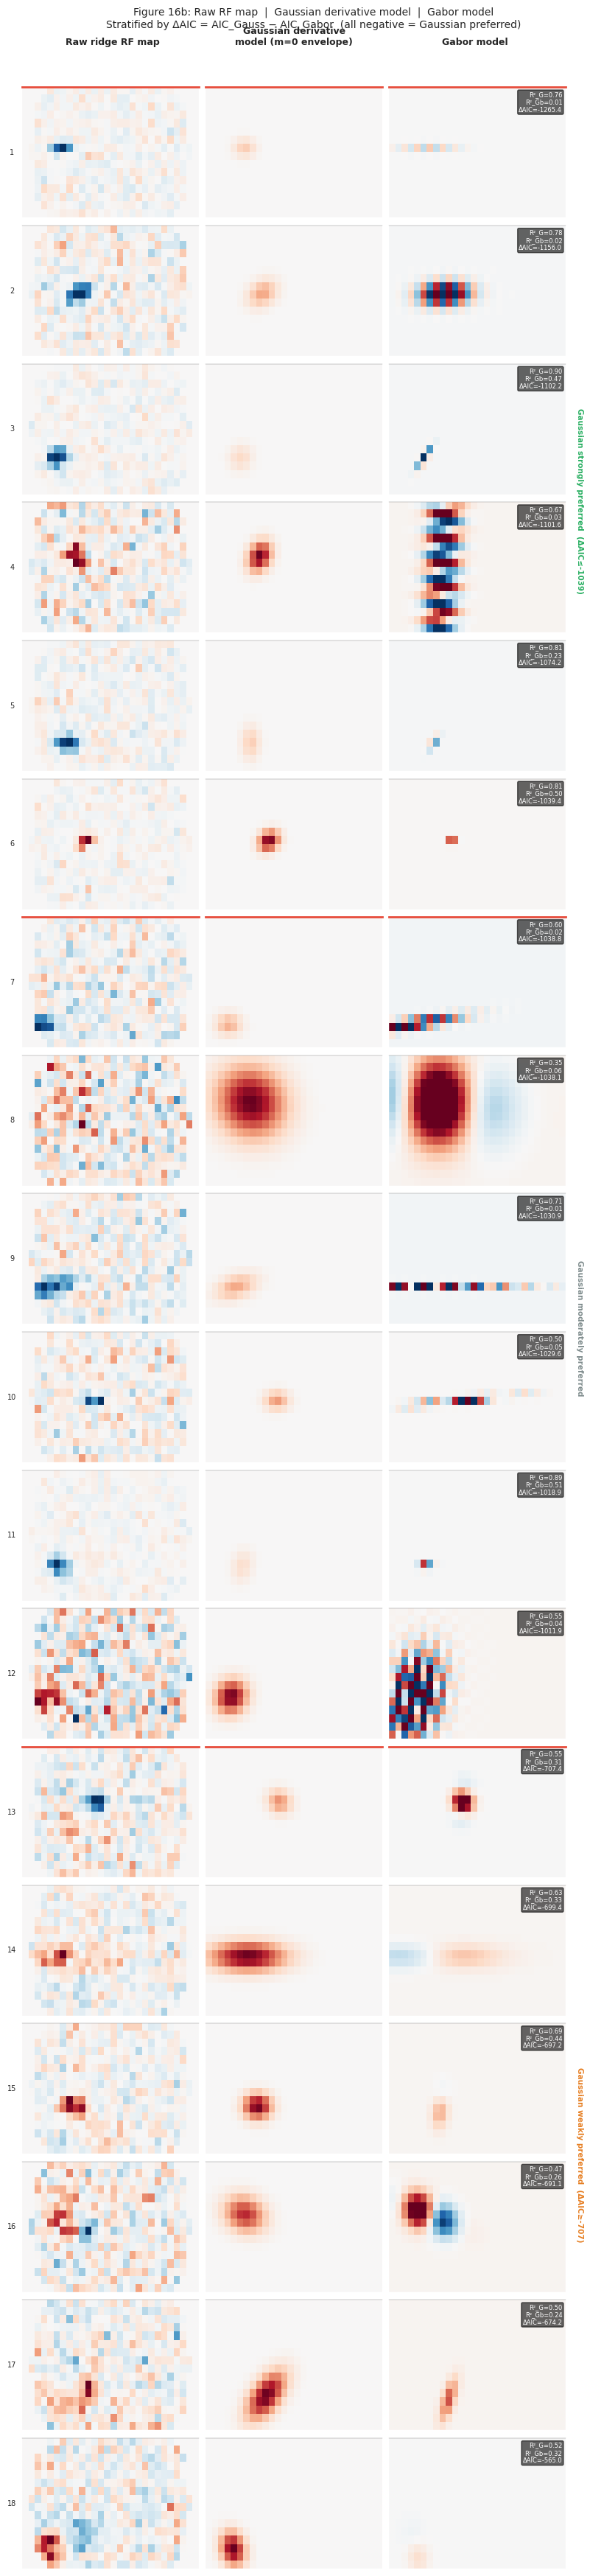

✓ Saved: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/fig16b_sidebyside_raw_gauss_gabor.png  (18 neurons)


In [16]:
# Figure 16b: Side-by-side gallery
# 3 columns: Raw RF map | Gaussian derivative model | Gabor model
# Rows stratified by ΔAIC. Load errors are skipped — only available neurons shown.

N_PER_GROUP = 6

# ── 1. Stratified sample by ΔAIC ─────────────────────────────────────────────
pool = cmp_df[cmp_df['r2_gauss'] >= 0.35].sort_values('delta_aic').reset_index(drop=True)

gauss_strong = pool.head(N_PER_GROUP).copy()
gauss_mid    = pool.iloc[N_PER_GROUP : N_PER_GROUP * 2].copy()
gauss_weak   = pool.tail(N_PER_GROUP).copy()

gallery16b = pd.concat([gauss_strong, gauss_mid, gauss_weak], ignore_index=True)
group_labels_all = (
    [f'Gaussian strongly preferred  (ΔAIC≤{gauss_strong["delta_aic"].max():.0f})'] * N_PER_GROUP +
    ['Gaussian moderately preferred']                                                * N_PER_GROUP +
    [f'Gaussian weakly preferred  (ΔAIC≥{gauss_weak["delta_aic"].min():.0f})']      * N_PER_GROUP
)

print(f'Gabor never preferred by AIC: all ΔAIC < 0 '
      f'({(pool["delta_aic"] < 0).mean()*100:.1f}% of neurons)')
print(f'Requested: {len(gallery16b)} neurons across '
      f'{gallery16b["exp_id"].nunique()} experiments')

# ── 2. Batch RF maps — robust cell_id ordering ────────────────────────────────
# AllenSDK requires cell_ids to be a subset of the experiment's own cell list
# in exactly the order that list is sorted. Numerically sorting is NOT sufficient
# — we must intersect with dataset.get_cell_specimen_ids() and preserve that order.

def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    """Like batch_get_rf_maps but handles cell_id ordering robustly.
    Intersects requested_ids with the experiment's actual cell list,
    preserving AllenSDK's required ordering. Returns {} if nothing valid.
    """
    # Experiment's canonical sorted cell list
    exp_cells  = list(dataset.get_cell_specimen_ids())   # already sorted by AllenSDK
    req_set    = set(int(c) for c in requested_ids)
    # Keep only requested IDs that exist, in the experiment's order
    valid_ids  = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError(f"None of {len(req_set)} requested cell_ids found in experiment "
                         f"(exp has {len(exp_cells)} cells)")

    stimulus_name = next(
        (s for s in dataset.list_stimuli() if 'sparse_noise' in s), None
    )
    if stimulus_name is None:
        raise ValueError("No sparse noise stimulus found.")

    stim_table    = dataset.get_stimulus_table(stimulus_name)
    tr            = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stimulus_name)
    template      = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size      = _pixel_size(stimulus_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    # Single NWB read — valid_ids are in the experiment's own order
    _, all_dff = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val, grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit = X[frame_valid].astype(np.float64)
    Y_fit = Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError("Too few valid presentations.")

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        from sklearn.linear_model import Ridge
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out


rf_cache16b = {}
for exp_id, grp in gallery16b.groupby('exp_id'):
    cell_ids_here = grp['cell_id'].astype(int).tolist()
    try:
        dataset = boc.get_ophys_experiment_data(int(exp_id))
        exp_cache = batch_get_rf_maps_safe(dataset, cell_ids_here)
        rf_cache16b.update(exp_cache)
        print(f'  ✓ exp {exp_id}: {len(exp_cache)}/{len(cell_ids_here)} RF maps loaded')
    except Exception as e:
        print(f'  ✗ exp {exp_id}: {e}')

# ── 3. Filter gallery to only rows with loaded RF maps ────────────────────────
available_mask = gallery16b['cell_id'].astype(int).isin(rf_cache16b)
gallery_plot   = gallery16b[available_mask].reset_index(drop=True)
group_labels   = [group_labels_all[i] for i in gallery16b[available_mask].index]

n_skipped = (~available_mask).sum()
print(f'\n✓ Plotting {len(gallery_plot)} neurons  '
      f'(skipped {n_skipped} with load errors)')

if len(gallery_plot) == 0:
    print('ERROR: no RF maps loaded — cannot plot.')
else:
    # ── 4. Figure: n_rows × 3 columns ────────────────────────────────────────
    n_rows = len(gallery_plot)
    fig = plt.figure(figsize=(9, n_rows * 1.9 + 2.0))
    gs  = gridspec.GridSpec(
        n_rows, 3, figure=fig,
        hspace=0.06, wspace=0.04,
        left=0.06, right=0.88, top=0.94, bottom=0.01
    )
    fig.suptitle(
        'Figure 16b: Raw RF map  |  Gaussian derivative model  |  Gabor model\n'
        'Stratified by ΔAIC = AIC_Gauss − AIC_Gabor  (all negative = Gaussian preferred)',
        fontsize=10, y=0.97
    )
    for col_i, title in enumerate(['Raw ridge RF map',
                                    'Gaussian derivative\nmodel (m=0 envelope)',
                                    'Gabor model']):
        x = 0.06 + col_i * (0.82 / 3) + (0.82 / 6)
        fig.text(x, 0.955, title, ha='center', va='bottom', fontsize=9, fontweight='bold')

    for row_i, (_, row) in enumerate(gallery_plot.iterrows()):
        cell_id = int(row['cell_id'])
        rf_map, pix = rf_cache16b[cell_id]
        ny, nx = rf_map.shape
        vmax   = max(np.abs(rf_map).max(), 1e-9)

        XX, YY = np.meshgrid(np.arange(nx, dtype=float), np.arange(ny, dtype=float))
        xy_pix = (XX.ravel(), YY.ravel())

        # Gaussian model
        gauss_row = all_df.loc[all_df['cell_id'] == cell_id]
        x0_p, y0_p = nx / 2.0, ny / 2.0   # fallback centre
        if len(gauss_row) == 0:
            gauss_model = np.zeros_like(rf_map)
        else:
            gr = gauss_row.iloc[0]
            try:
                x0_p = float(gr['x0'])      / pix
                y0_p = float(gr['y0'])      / pix
                sx_p = float(gr['sigma_x']) / pix
                sy_p = float(gr['sigma_y']) / pix
                th_r = np.deg2rad(float(gr['theta']))
                A_g  = float(rf_map.max()) or 1.0
                gauss_model = gaussian_2d(
                    xy_pix, A_g, x0_p, y0_p, sx_p, sy_p, th_r, 0.0
                ).reshape(ny, nx)
            except Exception:
                gauss_model = np.zeros_like(rf_map)

        # Gabor model
        try:
            sig_g  = float(row['sigma_gabor'])
            kap_g  = max(float(row['kappa_gabor']), 1.0)
            sx_gp  = sig_g * np.sqrt(kap_g) / pix
            sy_gp  = sig_g / np.sqrt(kap_g) / pix
            th_gr  = np.deg2rad(float(row['theta_gabor']))
            freq_p = float(row['freq_cpd']) * pix
            A_gb   = (float(rf_map.max()) - float(rf_map.min())) or 1.0
            gabor_model = gabor_2d(
                xy_pix, A_gb, x0_p, y0_p, sx_gp, sy_gp,
                th_gr, freq_p, float(row['phase_rad']), float(rf_map.mean())
            ).reshape(ny, nx)
        except Exception:
            gabor_model = np.zeros_like(rf_map)

        for col_i, img in enumerate([rf_map, gauss_model, gabor_model]):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.imshow(img, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                      aspect='auto', interpolation='nearest')
            ax.set_xticks([]); ax.set_yticks([])

            is_new = (row_i == 0 or group_labels[row_i] != group_labels[row_i - 1])
            ax.spines['top'].set_linewidth(2.0 if is_new else 0.3)
            ax.spines['top'].set_color('#e74c3c' if is_new else 'gray')
            for sp in ['bottom', 'left', 'right']:
                ax.spines[sp].set_linewidth(0.3)

            if col_i == 2:
                delta = row['delta_aic']
                col_txt = '#27ae60' if delta < -2 else ('#c0392b' if delta > 2 else '#888')
                ax.text(0.98, 0.97,
                        f'R²_G={row["r2_gauss"]:.2f}\n'
                        f'R²_Gb={row["r2_gabor"]:.2f}\n'
                        f'ΔAIC={delta:+.1f}',
                        transform=ax.transAxes, ha='right', va='top', fontsize=6,
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

        fig.axes[row_i * 3].set_ylabel(
            f'{row_i + 1}', fontsize=7, rotation=0, labelpad=10, va='center')

    # Group labels on right margin
    group_starts = [i for i in range(n_rows)
                    if i == 0 or group_labels[i] != group_labels[i - 1]]
    subplot_h = (0.94 - 0.01) / n_rows
    for si in group_starts:
        ei = si
        while ei + 1 < n_rows and group_labels[ei + 1] == group_labels[si]:
            ei += 1
        mid_y  = 0.94 - ((si + ei) / 2.0 + 0.5) * subplot_h
        colour = '#27ae60' if 'strongly' in group_labels[si] else (
                 '#7f8c8d' if 'moderately' in group_labels[si] else '#e67e22')
        fig.text(0.895, mid_y, group_labels[si], ha='left', va='center',
                 fontsize=7.5, rotation=270, color=colour, fontweight='bold')

    gallery_path = ridge_dir / 'fig16b_sidebyside_raw_gauss_gabor.png'
    plt.savefig(gallery_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {gallery_path}  ({n_rows} neurons)')

---

## Part 5: κ Comparison — Does Gabor recover the same elongation?

Since κ is the key parameter for the Lindeberg hypothesis, we specifically check
whether the Gabor envelope's κ (σ_x/σ_y of the Gaussian envelope) agrees with
the directly-fitted Gaussian κ. Strong agreement means our κ measurement is
model-independent — a major robustness argument.

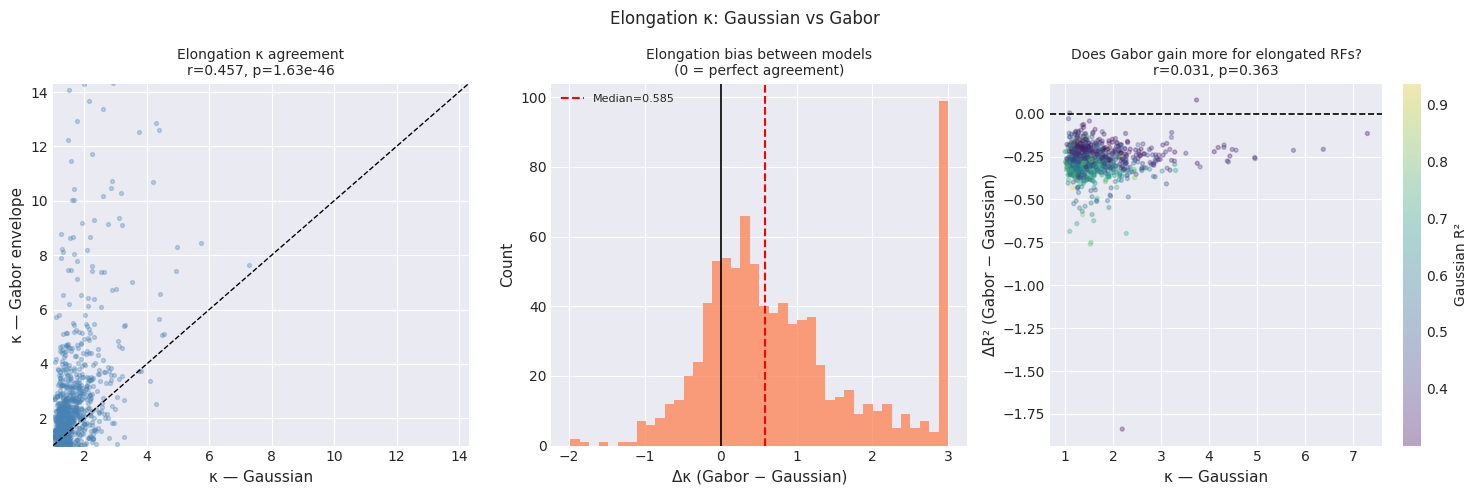

✓ Saved: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/fig_kappa_model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── κ scatter ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(cmp_df['kappa_gauss'], cmp_df['kappa_gabor'],
           alpha=0.3, s=8, rasterized=True, color='steelblue')
kmax = max(cmp_df['kappa_gauss'].quantile(0.99), cmp_df['kappa_gabor'].quantile(0.99)) + 0.2
ax.plot([1, kmax], [1, kmax], 'k--', linewidth=1)
ax.set_xlim(1, kmax); ax.set_ylim(1, kmax)
r_k, p_k = pearsonr(cmp_df['kappa_gauss'].clip(1, kmax),
                    cmp_df['kappa_gabor'].clip(1, kmax))
ax.set_xlabel('κ — Gaussian', fontsize=11)
ax.set_ylabel('κ — Gabor envelope', fontsize=11)
ax.set_title(f'Elongation κ agreement\nr={r_k:.3f}, p={p_k:.2e}', fontsize=10)

# ── Δκ distribution ───────────────────────────────────────────────────────────
ax = axes[1]
delta_kappa = cmp_df['kappa_gabor'] - cmp_df['kappa_gauss']
ax.hist(delta_kappa.clip(-3, 3), bins=40, edgecolor='none', alpha=0.75, color='coral')
ax.axvline(0, color='black', linewidth=1.2)
ax.axvline(delta_kappa.median(), color='red', linestyle='--',
           label=f'Median={delta_kappa.median():.3f}')
ax.set_xlabel('Δκ (Gabor − Gaussian)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Elongation bias between models\n(0 = perfect agreement)', fontsize=10)
ax.legend(fontsize=8)

# ── κ_gauss vs ΔR² — does elongation predict model difference? ───────────────
ax = axes[2]
sc = ax.scatter(cmp_df['kappa_gauss'], cmp_df['delta_r2'],
                c=cmp_df['r2_gauss'], cmap='viridis', alpha=0.3, s=8, rasterized=True)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.colorbar(sc, ax=ax, label='Gaussian R²')
r_kdr, p_kdr = pearsonr(cmp_df['kappa_gauss'], cmp_df['delta_r2'])
ax.set_xlabel('κ — Gaussian', fontsize=11)
ax.set_ylabel('ΔR² (Gabor − Gaussian)', fontsize=11)
ax.set_title(f'Does Gabor gain more for elongated RFs?\nr={r_kdr:.3f}, p={p_kdr:.3f}', fontsize=10)

fig.suptitle('Elongation κ: Gaussian vs Gabor', fontsize=12)
plt.tight_layout()
kappa_path = ridge_dir / 'fig_kappa_model_comparison.png'
plt.savefig(kappa_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {kappa_path}')

---

## Part 6: Summary Statistics & Interpretation

In [10]:
from scipy.stats import wilcoxon

# ── Statistical tests ─────────────────────────────────────────────────────────
stat_r2,   p_r2   = wilcoxon(cmp_df['r2_gauss'], cmp_df['r2_gabor'])
stat_rmse, p_rmse = wilcoxon(cmp_df['rmse_gauss'], cmp_df['rmse_gabor'])
stat_aic,  p_aic  = wilcoxon(cmp_df['aic_gauss'], cmp_df['aic_gabor'])

r_theta, p_theta = pearsonr(cmp_df['theta_gauss'], cmp_df['theta_gabor'])
r_sigma, p_sigma = pearsonr(cmp_df['sigma_gauss'], cmp_df['sigma_gabor'])
r_kappa, p_kappa = pearsonr(
    cmp_df['kappa_gauss'].clip(1, 5), cmp_df['kappa_gabor'].clip(1, 5)
)

print('=' * 65)
print('GAUSSIAN DERIVATIVE vs GABOR — SUMMARY')
print('=' * 65)

print(f'\nDataset: {len(cmp_df):,} neurons  |  '
      f'{cmp_df["container_id"].nunique()} containers')

print(f'\n--- Fit Quality ---')
print(f'  Gaussian:  R²={cmp_df["r2_gauss"].mean():.3f}±{cmp_df["r2_gauss"].std():.3f}  '
      f'RMSE={cmp_df["rmse_gauss"].mean():.4f}±{cmp_df["rmse_gauss"].std():.4f}')
print(f'  Gabor:     R²={cmp_df["r2_gabor"].mean():.3f}±{cmp_df["r2_gabor"].std():.3f}  '
      f'RMSE={cmp_df["rmse_gabor"].mean():.4f}±{cmp_df["rmse_gabor"].std():.4f}')
print(f'  Wilcoxon (R²):   W={stat_r2:.0f},  p={p_r2:.3e}')
print(f'  Wilcoxon (RMSE): W={stat_rmse:.0f}, p={p_rmse:.3e}')

print(f'\n--- AIC (parsimony) ---')
print(f'  Gaussian AIC: {cmp_df["aic_gauss"].mean():.1f}±{cmp_df["aic_gauss"].std():.1f}')
print(f'  Gabor AIC:    {cmp_df["aic_gabor"].mean():.1f}±{cmp_df["aic_gabor"].std():.1f}')
print(f'  ΔAIC median (Gauss−Gabor): {cmp_df["delta_aic"].median():.2f}')
print(f'  Gaussian preferred (ΔAIC<0): {(cmp_df["delta_aic"]<0).mean()*100:.1f}%')
print(f'  Wilcoxon (AIC):  W={stat_aic:.0f}, p={p_aic:.3e}')

print(f'\n--- Parameter Agreement ---')
print(f'  r(θ_Gauss, θ_Gabor) = {r_theta:.3f}  (p={p_theta:.2e})')
print(f'  r(σ_Gauss, σ_Gabor) = {r_sigma:.3f}  (p={p_sigma:.2e})')
print(f'  r(κ_Gauss, κ_Gabor) = {r_kappa:.3f}  (p={p_kappa:.2e})')

print(f'\n--- Interpretation ---')

# Infer which model wins on each metric and print conclusion
gauss_r2_better = cmp_df['r2_gauss'].mean() >= cmp_df['r2_gabor'].mean()
gauss_aic_better = (cmp_df['delta_aic'] < 0).mean() > 0.5

if gauss_r2_better and gauss_aic_better:
    print('  ✓ Gaussian derivative matches or exceeds Gabor on R² AND AIC.')
    print('    Lindeberg framework justified: better parsimony, equivalent fit.')
elif not gauss_r2_better and gauss_aic_better:
    print('  ~ Gabor has marginally higher R², but Gaussian wins on AIC.')
    print('    Gabors exploit 2 extra parameters for small gain — not justified.')
    print('    Gaussian derivative is preferred for the Lindeberg framework.')
elif gauss_r2_better and not gauss_aic_better:
    print('  ~ Gaussian has higher R² but Gabor preferred by AIC in majority.')
    print('    Check convergence rate of Gabor fits; possible over-regularisation.')
else:
    print('  ! Gabor outperforms Gaussian on both R² and AIC.')
    print('    Consider whether the ON-OFF combined RF retains sinusoidal structure.')
    print('    Gabor phase parameter may be capturing real sub-field asymmetry.')

theta_ok = r_theta > 0.8
sigma_ok = r_sigma > 0.8
kappa_ok = r_kappa > 0.7
print(f'\n  Parameter robustness:')
print(f'    θ: r={r_theta:.3f}  {"✓ robust" if theta_ok else "✗ models disagree"}')
print(f'    σ: r={r_sigma:.3f}  {"✓ robust" if sigma_ok else "✗ models disagree"}')
print(f'    κ: r={r_kappa:.3f}  {"✓ robust" if kappa_ok else "✗ models disagree"}')

if all([theta_ok, sigma_ok, kappa_ok]):
    print('\n  Spatial parameters (σ, θ, κ) are consistent across models.')
    print('  Results from notebook 05 are model-robust. Proceed to notebook 07.')
else:
    print('\n  WARNING: Parameter agreement below threshold for one or more parameters.')
    print('  Investigate discrepant neurons before proceeding to cross-validation.')

GAUSSIAN DERIVATIVE vs GABOR — SUMMARY

Dataset: 878 neurons  |  17 containers

--- Fit Quality ---
  Gaussian:  R²=0.523±0.153  RMSE=0.0004±0.0006
  Gabor:     R²=0.248±0.157  RMSE=0.0010±0.0017
  Wilcoxon (R²):   W=7,  p=2.688e-145
  Wilcoxon (RMSE): W=0, p=2.624e-145

--- AIC (parsimony) ---
  Gaussian AIC: -8044.1±1520.1
  Gabor AIC:    -7180.6±1516.2
  ΔAIC median (Gauss−Gabor): -865.03
  Gaussian preferred (ΔAIC<0): 100.0%
  Wilcoxon (AIC):  W=0, p=2.624e-145

--- Parameter Agreement ---
  r(θ_Gauss, θ_Gabor) = 0.468  (p=5.95e-49)
  r(σ_Gauss, σ_Gabor) = 0.520  (p=4.49e-62)
  r(κ_Gauss, κ_Gabor) = 0.461  (p=1.85e-47)

--- Interpretation ---
  ✓ Gaussian derivative matches or exceeds Gabor on R² AND AIC.
    Lindeberg framework justified: better parsimony, equivalent fit.

  Parameter robustness:
    θ: r=0.468  ✗ models disagree
    σ: r=0.520  ✗ models disagree
    κ: r=0.461  ✗ models disagree

  Investigate discrepant neurons before proceeding to cross-validation.


In [11]:
# Save full comparison DataFrame for reference in nb07
out_cmp = ridge_dir / 'gaussian_vs_gabor_comparison.csv'   # lives alongside ridge results
cmp_df.to_csv(out_cmp, index=False)
print(f'✓ Comparison results saved: {out_cmp}')
print(f'  Shape: {cmp_df.shape}')
print(f'  Columns: {cmp_df.columns.tolist()}')

✓ Comparison results saved: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/ridge/gaussian_vs_gabor_comparison.csv
  Shape: (878, 27)
  Columns: ['cell_id', 'container_id', 'exp_id', 'r2_gauss', 'rmse_gauss', 'aic_gauss', 'r2_gabor', 'rmse_gabor', 'aic_gabor', 'converged_gabor', 'sigma_gabor', 'theta_gabor', 'kappa_gabor', 'freq_cpd', 'phase_rad', 'sigma_gauss', 'theta_gauss', 'kappa_gauss', 'sigma_x', 'sigma_y', 'cortex_x_um', 'cortex_y_um', 'cre_line', 'depth_um', 'delta_aic', 'delta_r2', 'winner']
